In [4]:
# 1. Order and Sales Analysis

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import mysql.connector

In [11]:
# Connect to MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='alt_mobility',
)
cursor = conn.cursor()

In [19]:
# 1.1 Distribution of Orders by Status (Pie Chart)

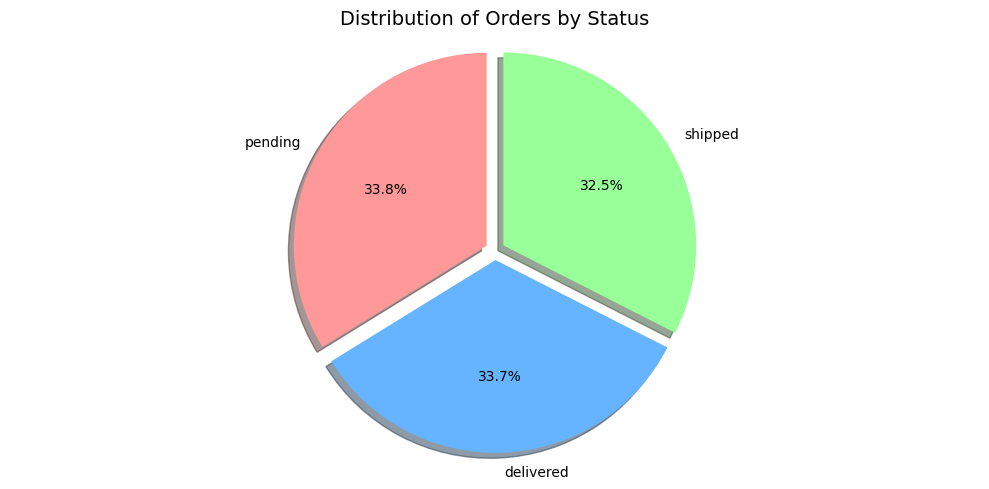

In [20]:
query1 = """
SELECT 
    order_status,
    COUNT(*) AS order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customer_orders), 2) AS percentage
FROM customer_orders
GROUP BY order_status
ORDER BY order_count DESC;
"""

cursor.execute(query1)
rows = cursor.fetchall()

df_status = pd.DataFrame(rows, columns=['order_status', 'order_count', 'percentage'])

# Plotting
plt.figure(figsize=(10, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0.05, 0.05)

plt.pie(df_status['percentage'], 
        labels=df_status['order_status'], 
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        colors=colors,
        shadow=True)

plt.title('Distribution of Orders by Status', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [16]:
# 1.2 Monthly Sales Trends (Time Series)

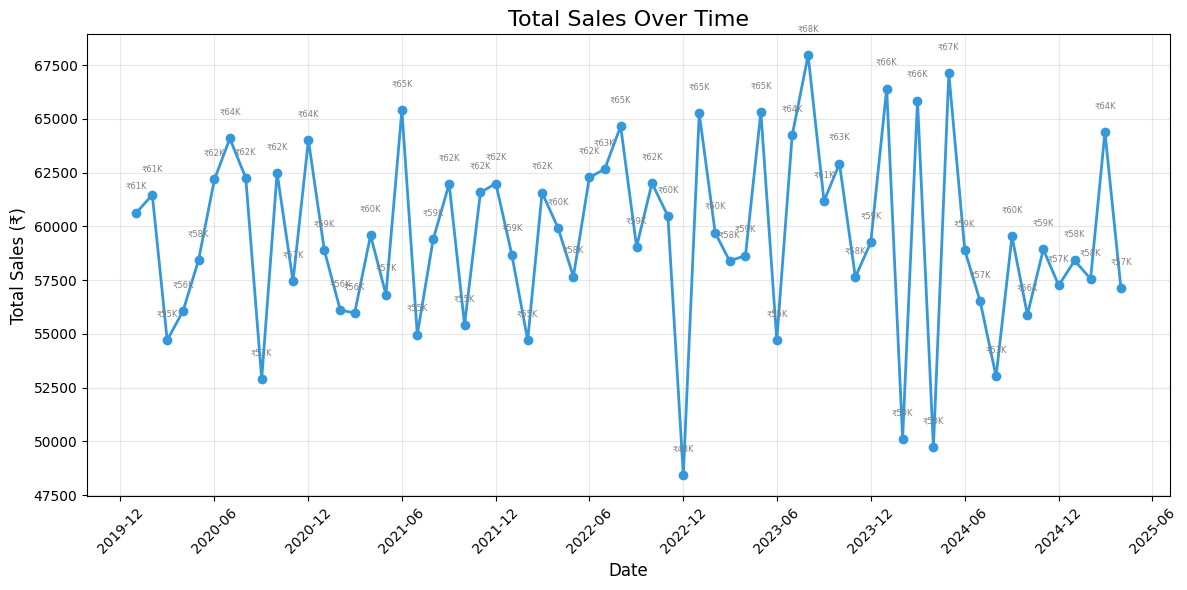

In [48]:
query1 = """
SELECT 
    EXTRACT(YEAR FROM order_date) AS year,
    EXTRACT(MONTH FROM order_date) AS month,
    COUNT(*) AS order_count,
    ROUND(SUM(order_amount), 2) AS total_sales,
    ROUND(AVG(order_amount), 2) AS average_order_value
FROM customer_orders
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query1)
rows = cursor.fetchall()
df_monthly_sales = pd.DataFrame(rows, columns=['year', 'month', 'order_count', 'total_sales', 'average_order_value'])

df_monthly_sales['date'] = pd.to_datetime(df_monthly_sales[['year', 'month']].assign(day=1))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_sales['date'], df_monthly_sales['total_sales'], marker='o', linestyle='-', linewidth=2, color='#3498db')

# Annotate points with values
for i in range(len(df_monthly_sales)):
    plt.text(df_monthly_sales['date'].iloc[i], df_monthly_sales['total_sales'].iloc[i] + 1000, 
             f'₹{df_monthly_sales["total_sales"].iloc[i]/1000:.0f}K', 
             ha='center', va='bottom', fontsize=6, color='grey')

plt.title('Total Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [25]:
# 2. Customer Analysis

In [26]:
# 2.1 Monthly Active Customers (Time Series)

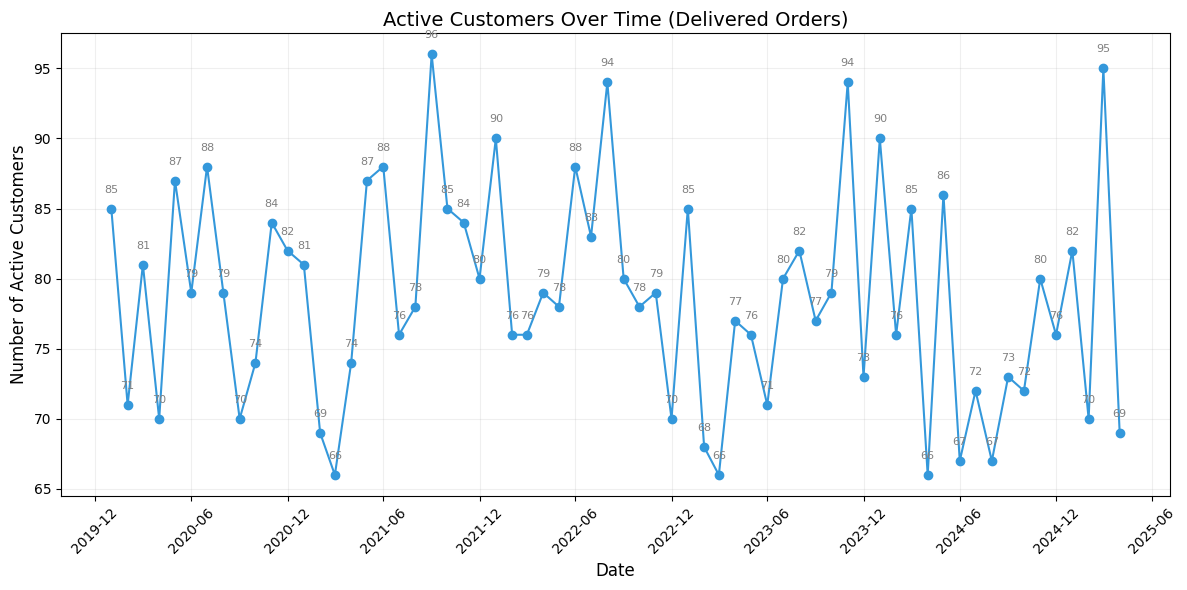

In [51]:
query1 = """
SELECT 
    EXTRACT(YEAR FROM order_date) AS year,
    EXTRACT(MONTH FROM order_date) AS month,
    COUNT(DISTINCT customer_id) AS active_customers,
    COUNT(*) AS total_orders
FROM customer_orders
WHERE order_status = 'delivered'
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query1)
rows = cursor.fetchall()

df_monthly_active = pd.DataFrame(rows, columns=['year', 'month', 'active_customers', 'total_orders'])
df_monthly_active['date'] = pd.to_datetime(df_monthly_active[['year', 'month']].assign(day=1))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_active['date'], df_monthly_active['active_customers'], marker='o', linestyle='-', color='#3498db')

# Annotate points
for i in range(len(df_monthly_active)):
    plt.text(df_monthly_active['date'].iloc[i], df_monthly_active['active_customers'].iloc[i] + 1, 
             f'{df_monthly_active["active_customers"].iloc[i]}', 
             ha='center', va='bottom', fontsize=8, color='grey')

plt.title('Active Customers Over Time (Delivered Orders)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Active Customers', fontsize=12)
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
# 2.2 Customer Segmentation by Spending (Pie Chart)

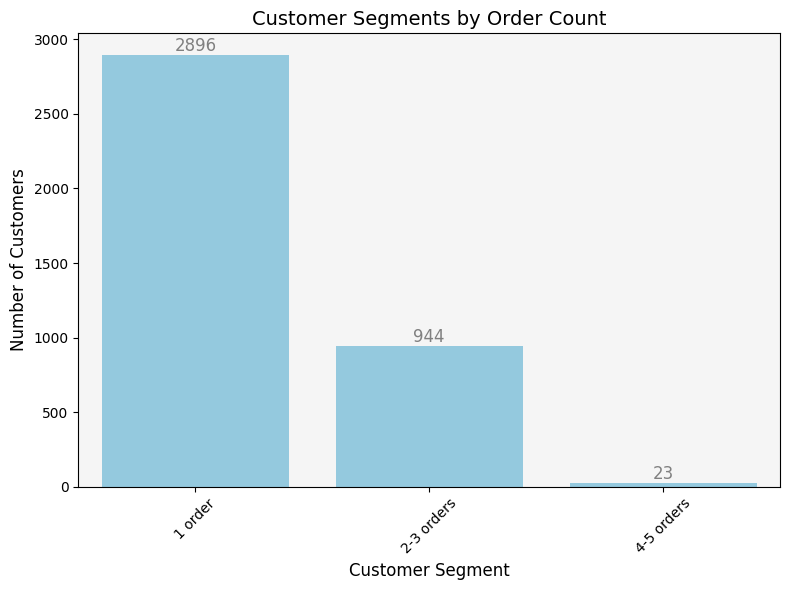

In [52]:
query2 = """
WITH customer_stats AS (
    SELECT 
        customer_id,
        COUNT(*) AS order_count,
        SUM(order_amount) AS total_spent,
        AVG(order_amount) AS average_order_value,
        EXTRACT(DAY FROM MAX(order_date) - MIN(order_date)) AS customer_lifetime_days
    FROM customer_orders
    WHERE order_status = 'delivered'
    GROUP BY customer_id
)

SELECT 
    CASE 
        WHEN order_count = 1 THEN '1 order'
        WHEN order_count BETWEEN 2 AND 3 THEN '2-3 orders'
        WHEN order_count BETWEEN 4 AND 5 THEN '4-5 orders'
        ELSE '6+ orders'
    END AS customer_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(total_spent), 2) AS avg_total_spent,
    ROUND(AVG(average_order_value), 2) AS avg_order_value,
    ROUND(AVG(customer_lifetime_days), 0) AS avg_lifetime_days
FROM customer_stats
GROUP BY customer_segment
"""

cursor.execute(query2)
rows = cursor.fetchall()

df2 = pd.DataFrame(rows, columns=["customer_segment", "customer_count", "avg_total_spent", "avg_order_value", "avg_lifetime_days"])

# Create the seaborn bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x="customer_segment", y="customer_count", data=df2, color='skyblue')

# label
for i in range(len(df2)):
    plt.text(x=df2["customer_segment"].iloc[i], 
             y=df2["customer_count"].iloc[i], 
             s=str(df2["customer_count"].iloc[i]), 
             ha='center', va='bottom', fontsize=12, color='grey')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)  
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)
plt.grid(False) # Remove grid

# Title and labels
plt.title("Customer Segments by Order Count", fontsize=14)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()



In [55]:
# 2.3 Customer Segmentation by Spending

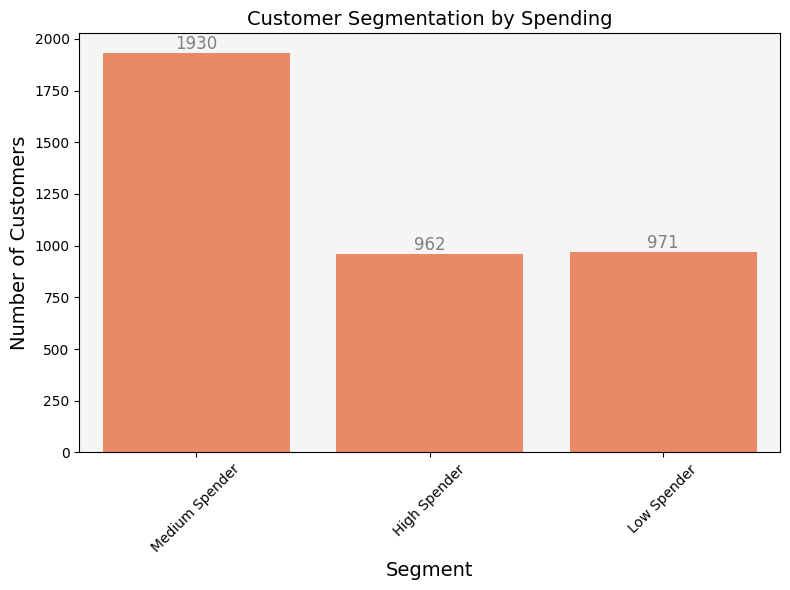

In [53]:
query3 = """
WITH customer_stats AS (
    SELECT 
        customer_id,
        SUM(order_amount) AS total_spend
    FROM customer_orders
    WHERE order_status = 'delivered'
    GROUP BY customer_id
)
SELECT 
    CASE 
        WHEN total_spend >= 448 THEN 'High Spender'
        WHEN total_spend BETWEEN 170 AND 447 THEN 'Medium Spender'
        ELSE 'Low Spender'
    END AS segment,
    COUNT(*) AS customers,
    ROUND(AVG(total_spend), 2) AS avg_spend,
    ROUND(SUM(total_spend), 2) AS total_revenue
FROM customer_stats
GROUP BY segment
ORDER BY total_revenue DESC;
"""

cursor.execute(query3)
rows = cursor.fetchall()

df = pd.DataFrame(rows, columns=["segment", "customers", "avg_spend", "total_revenue"])

# Visualization
plt.figure(figsize=(8, 6))
sns.barplot(x="segment", y="customers", data=df, color='coral')

# label
for i in range(len(df)):
    plt.text(x=df["segment"].iloc[i], 
             y=df["customers"].iloc[i], 
             s=str(df["customers"].iloc[i]), 
             ha='center', va='bottom', fontsize=12, color='grey')

# Adjust font size for labels
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#F5F5F5')  # Set axes' background to white (or any color you prefer)
plt.grid(False) # Remove grid

plt.title("Customer Segmentation by Spending", fontsize=14)
plt.xlabel("Segment", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)
plt.tight_layout()
plt.show()


In [57]:
# 3. PAYMENT STATUS ANALYSIS

In [58]:
# 3.1 Payment Status Distribution (Pie Chart)

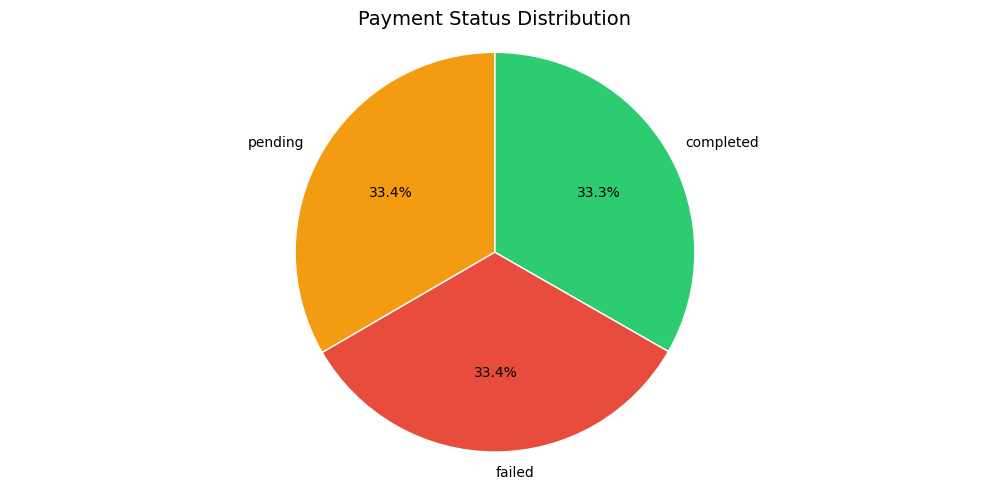

In [62]:
query3 = """
SELECT 
    payment_status,
    COUNT(*) AS payment_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM payments), 2) AS percentage,
    ROUND(SUM(payment_amount), 2) AS total_amount,
    ROUND(AVG(payment_amount), 2) AS average_amount
FROM payments
GROUP BY payment_status
ORDER BY payment_count DESC;
"""

cursor.execute(query3)
rows = cursor.fetchall()

df_payment_status = pd.DataFrame(rows, columns=['payment_status', 'payment_count', 'percentage', 'total_amount', 'average_amount'])

# Plotting
plt.figure(figsize=(10, 5))
colors = {'completed': '#2ecc71', 'pending': '#f39c12', 'failed': '#e74c3c'}
plt.pie(df_payment_status['percentage'],
        labels=df_payment_status['payment_status'],
        autopct='%1.1f%%',
        startangle=90,
        colors=[colors[status] for status in df_payment_status['payment_status']],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})

plt.title('Payment Status Distribution', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [31]:
# 3.2 Payment Success and Failure Rates by Method (Bar Chart)

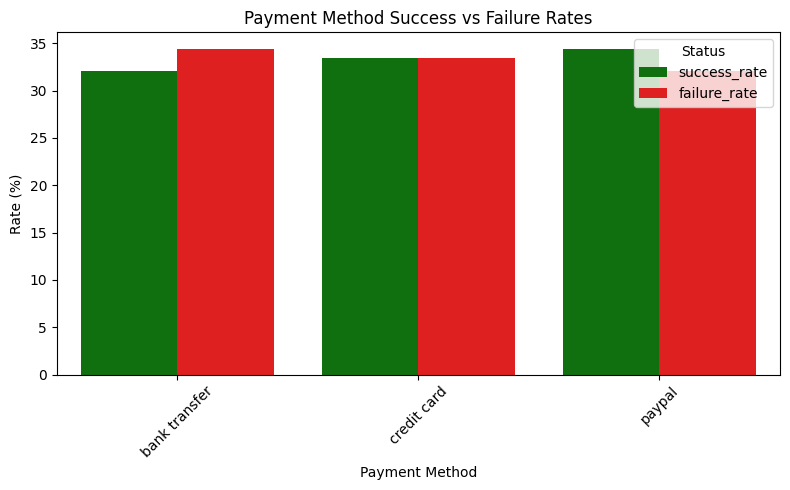

In [71]:
query3 = """
SELECT 
    payment_method,
    ROUND(SUM(CASE WHEN payment_status = 'completed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS success_rate,
    ROUND(SUM(CASE WHEN payment_status = 'failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate
FROM payments
GROUP BY payment_method
ORDER BY failure_rate DESC;
"""

# Execute query
cursor.execute(query3)
rows = cursor.fetchall()

# Convert to DataFrame
df_payment_method_analysis = pd.DataFrame(rows, columns=['payment_method', 'success_rate', 'failure_rate'])

# Melt the DataFrame for Seaborn
df_melted = df_payment_method_analysis.melt(
    id_vars='payment_method', 
    value_vars=['success_rate', 'failure_rate'],
    var_name='Status', 
    value_name='Rate'
)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x='payment_method', y='Rate', hue='Status', palette=['green', 'red'])

plt.title('Payment Method Success vs Failure Rates')
plt.ylabel('Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [32]:
# 4. Order Fulfillment Performance Metrics

In [33]:
# 4.1 Order Fulfillment Status Over Time (Stackplot)

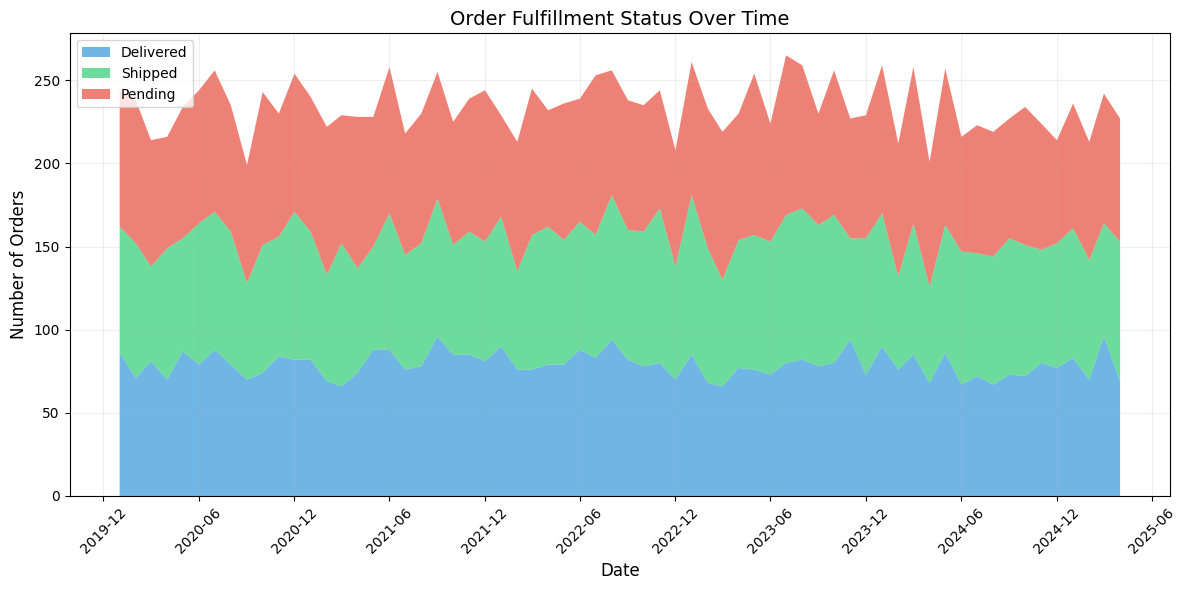

In [76]:
query3 = """
SELECT 
    EXTRACT(YEAR FROM order_date) AS year,
    EXTRACT(MONTH FROM order_date) AS month,
    COUNT(CASE WHEN order_status = 'delivered' THEN 1 END) AS delivered_orders,
    COUNT(CASE WHEN order_status = 'shipped' THEN 1 END) AS shipped_orders,
    COUNT(CASE WHEN order_status = 'pending' THEN 1 END) AS pending_orders
FROM customer_orders
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query3)
rows = cursor.fetchall()

df_fulfillment = pd.DataFrame(rows, columns=['year', 'month', 'delivered_orders', 'shipped_orders', 'pending_orders'])

df_fulfillment['date'] = pd.to_datetime(df_fulfillment[['year', 'month']].assign(day=1))

# Plotting
plt.figure(figsize=(12, 6))
plt.stackplot(df_fulfillment['date'],
              df_fulfillment['delivered_orders'],
              df_fulfillment['shipped_orders'],
              df_fulfillment['pending_orders'],
              labels=['Delivered', 'Shipped', 'Pending'],
              colors=['#3498db', '#2ecc71', '#e74c3c'],
              alpha=0.7)

plt.title('Order Fulfillment Status Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# 4.2 Seasonal Patterns in Fulfillment Rates (Line Plot)

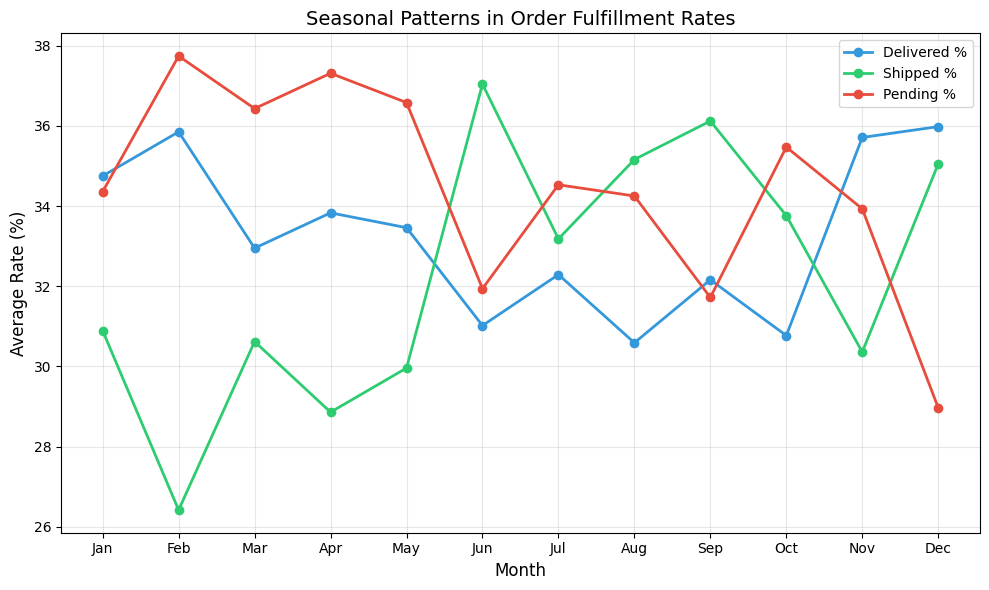

In [87]:
query3 = """
SELECT 
    EXTRACT(YEAR FROM order_date) AS year,
    EXTRACT(MONTH FROM order_date) AS month,
    ROUND(COUNT(CASE WHEN order_status = 'delivered' THEN 1 END) * 100.0 / COUNT(*), 2) AS delivery_rate,
    ROUND(COUNT(CASE WHEN order_status = 'shipped' THEN 1 END) * 100.0 / COUNT(*), 2) AS shipped_rate,
    ROUND(COUNT(CASE WHEN order_status = 'pending' THEN 1 END) * 100.0 / COUNT(*), 2) AS pending_rate
FROM customer_orders
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query3)
rows = cursor.fetchall()

df_fulfillment = pd.DataFrame(rows, columns=['year', 'month', 'delivery_rate', 'shipped_rate', 'pending_rate'])
df_fulfillment = df_fulfillment[df_fulfillment['year'] == 2024]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(monthly_fulfillment['month'], monthly_fulfillment['delivery_rate'], 'o-', 
         label='Delivered %', color='#3498db', linewidth=2)
plt.plot(monthly_fulfillment['month'], monthly_fulfillment['shipped_rate'], 'o-', 
         label='Shipped %', color='#2ecc71', linewidth=2)
plt.plot(monthly_fulfillment['month'], monthly_fulfillment['pending_rate'], 'o-', 
         label='Pending %', color='#e74c3c', linewidth=2)

plt.title('Seasonal Patterns in Order Fulfillment Rates', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rate (%)', fontsize=12)
plt.xticks(monthly_fulfillment['month'], 
          ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# 5. Yearly-Monthly Revenue Report

In [36]:
# 5.1 Order Amount vs Payment Amount Over Time (Line Plot)

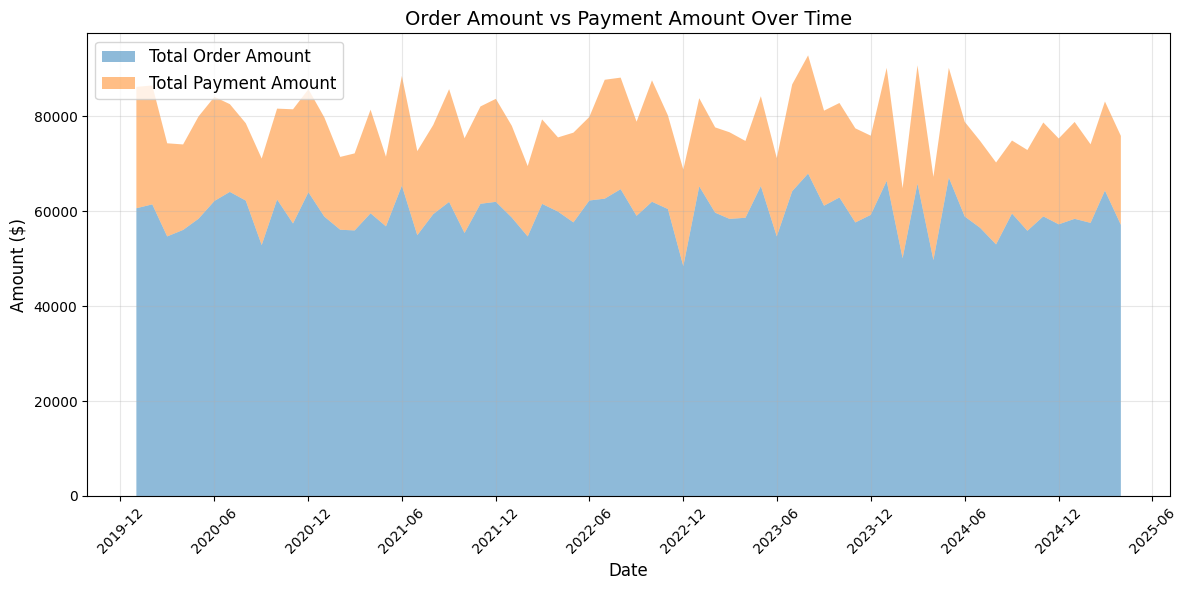

In [86]:
# Define the SQL query with aggregation
query3 = """
WITH orders_agg AS (
    SELECT
        order_id,
        order_date,
        SUM(order_amount) AS t_order_amount
    FROM customer_orders
    GROUP BY order_id, order_date
),
payments_agg AS (
    SELECT 
        order_id,
        COUNT(DISTINCT p.payment_id) AS t_payments,
        SUM(p.payment_amount) AS t_payment_amount
    FROM payments p
    WHERE p.payment_status = 'completed'
    GROUP BY order_id
)
SELECT 
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    ROUND(SUM(o.t_order_amount), 2) AS total_order_amount,
    ROUND(SUM(p.t_payment_amount), 2) AS total_payment_amount
FROM orders_agg o
LEFT JOIN payments_agg p ON o.order_id = p.order_id
GROUP BY year, month
ORDER BY year, month;
"""

# Execute the query and fetch the results
cursor.execute(query3)
rows = cursor.fetchall()

# Convert the results into a DataFrame
df_revenue = pd.DataFrame(rows, columns=['year', 'month', 'total_order_amount', 'total_payment_amount'])

# Create a 'date' column to represent the first day of each month
df_revenue['date'] = pd.to_datetime(df_revenue[['year', 'month']].assign(day=1))

# Stacked Area Chart for visualization
plt.figure(figsize=(12, 6))

# Plotting the stacked area chart
plt.stackplot(df_revenue['date'], df_revenue['total_order_amount'], df_revenue['total_payment_amount'],
             labels=['Total Order Amount', 'Total Payment Amount'], alpha=0.5)

# Adding titles and labels
plt.title('Order Amount vs Payment Amount Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)

# Adding legend
plt.legend(loc='upper left', fontsize=12)

# Grid and x-axis formatting for better readability
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# Rotating x-axis labels for better readability
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Adjusting layout to ensure everything fits well
plt.tight_layout()

# Display the plot
plt.show()


In [37]:
# 5.2 Average Revenue Gap Percentage by Year (Bar Chart)

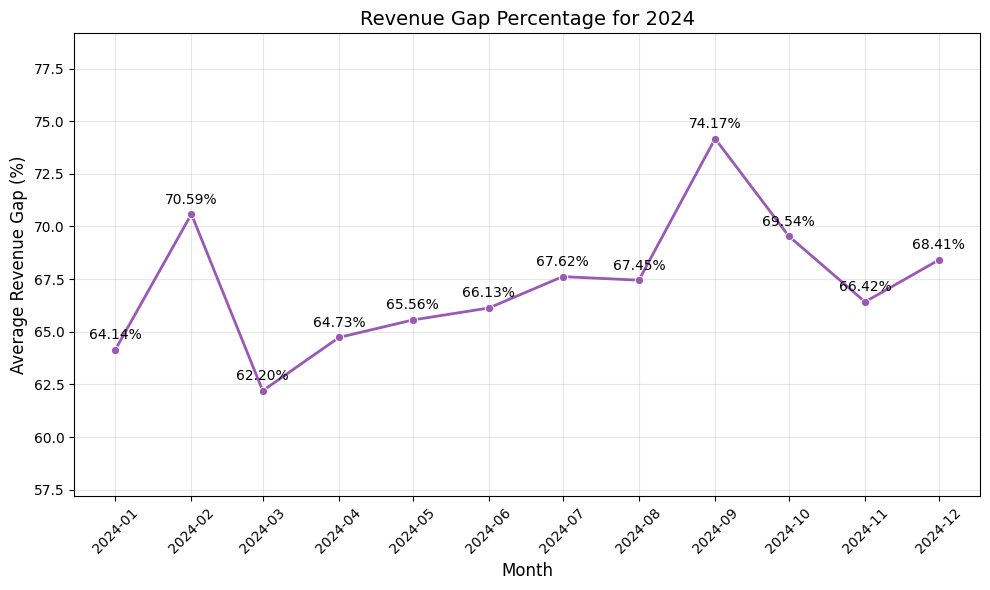

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assuming the query execution and DataFrame loading is correct
query3 = """
WITH orders_agg AS (
    SELECT
        order_id,
        order_date,
        SUM(order_amount) AS t_order_amount
    FROM customer_orders
    GROUP BY order_id, order_date
),
payments_agg AS (
    SELECT 
        order_id,
        COUNT(DISTINCT p.payment_id) AS t_payments,
        SUM(p.payment_amount) AS t_payment_amount
    FROM payments p
    WHERE p.payment_status = 'completed'
    GROUP BY order_id
)
SELECT 
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    ROUND(
        (SUM(o.t_order_amount) - COALESCE(SUM(p.t_payment_amount), 0)) * 100.0 / SUM(o.t_order_amount), 
        2
    ) AS revenue_gap_percentage
FROM orders_agg o
LEFT JOIN payments_agg p ON o.order_id = p.order_id
GROUP BY year, month
ORDER BY year, month;
"""

cursor.execute(query3)
rows = cursor.fetchall()

# Create a DataFrame from the results
yearly_revenue = pd.DataFrame(rows, columns=['year', 'month', 'revenue_gap_percentage'])

# Convert to datetime with the first day of each month
yearly_revenue['date'] = pd.to_datetime(yearly_revenue[['year', 'month']].assign(day=1))

# Filter for the year 2024
df_2024 = yearly_revenue[yearly_revenue['year'] == 2024]

# Plotting using Seaborn Line Chart
plt.figure(figsize=(10, 6))

# Create the lineplot
sns.lineplot(x='date', y='revenue_gap_percentage', data=df_2024, marker='o', color='#9b59b6', linewidth=2)

# Add percentage labels on the plot
for i in range(len(df_2024)):
    plt.text(df_2024['date'].iloc[i], df_2024['revenue_gap_percentage'].iloc[i] + 0.5, 
             f'{df_2024["revenue_gap_percentage"].iloc[i]:.2f}%', 
             ha='center', fontsize=10)

# Set chart title and labels
plt.title('Revenue Gap Percentage for 2024', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Revenue Gap (%)', fontsize=12)

# Format x-axis to display month-year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format x-axis as Year-Month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Show every month for 2024

# Rotate x-axis labels for readability
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Set y-axis limits for better visualization
plt.ylim(df_2024['revenue_gap_percentage'].min() - 5, df_2024['revenue_gap_percentage'].max() + 5)

# Grid and layout adjustments
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()


# Analysis Report for Alt Mobility

## Key Findings

### 1. Order and Sales Analysis
- **Order Status Distribution**: Orders are nearly evenly split among `pending` (33.79%), `delivered` (33.71%), and `shipped` (32.49%).
- **Monthly Sales Trends**: Sales show seasonal fluctuations, with peaks in mid-year (June-August) and year-end (December). The average order value ranges between `₹232.88` and `₹271.03`.
- **High-Value Orders**: Identified 100 high-value orders (above average), with amounts close to ₹500. These orders are primarily in `shipped` or `pending` status.
- **Payment Method Performance**:  
  - **Bank Transfer**: Most used (34.03%) but has the highest failure rate (34.44%).  
  - **Credit Card**: Moderate usage (33.17%) with a 33.48% failure rate.  
  - **PayPal**: Lowest usage (32.79%) but highest success rate (34.42%).

### 2. Customer Analysis
- **Customer Segmentation**:  
  - **High Spenders(`>= ₹448`) (962 customers)**: Contribute 45% of total revenue (₹592,886).  
  - **Medium Spenders(`Between ₹170 AND ₹447`) (1,930 customers)**: Contribute 49% of revenue (₹599,897).  
  - **Low Spenders(`< ₹170`) (971 customers)**: Contribute 6% of revenue (₹91,833).  
- **Repeat Orders**:  
  - New orders dominate initially, but repeat orders grow over time, peaking at 187 repeat orders in April 2025.  
  - Customers with 2-3 orders have a 10-day average lifetime, while 4-5 orders show 7 days.  
- **Active Customers**: Monthly active customers range between 66 and 96, with consistent delivery rates.

### 3. Payment Status Analysis
- **Payment Status Distribution**:  
  - `pending` (33.37%), `failed` (33.35%), and `completed` (33.27%) are evenly split.  
- **Failure Trends**:  
  - Bank transfers have the highest failure rate (34.44%), while PayPal has the lowest (32.10%).  
  - Some orders have up to 7 payment attempts, with delays spanning 921 days. 

  ### 💸 Payment Method Performance
  | Method         | % of Payments | Total Amount | Avg Payment | Success Rate |
  |----------------|----------------|----------------|----------------|----------------|
  | Bank Transfer  | 34.0%          | ₹1.3M          | ₹254.9         | 32.0%          |
  | Credit Card    | 33.2%          | ₹1.26M         | ₹254.0         | 33.4%          |
  | PayPal         | 32.8%          | ₹1.24M         | ₹251.9         | **34.4%**   | 

---

## Observations from Customer Retention Analysis
- **Low Retention**: 2,896 customers (61%) placed only one order, indicating low retention.  
- **High-Value Potential**: Customers with 6+ orders spend significantly more (avg. ₹616 vs. ₹255 for one-time buyers).  
- **Lifetime Value**: High spenders have longer lifetimes (avg. 10 days vs. 0 for one-time buyers).  

---

## Recommendations for Alt Mobility
1. **Improve Payment Success Rates**:  
   - Investigate and resolve issues with bank transfers (highest failure rate).  
   - Promote PayPal (highest success rate) through incentives.  

2. **Enhance Customer Retention**:  
   - Launch loyalty programs for repeat customers (e.g., discounts for 2+ orders).  
   - Target high spenders with personalized offers to encourage repeat purchases.  

3. **Optimize Order Fulfillment**:  
   - Address discrepancies in order vs. payment amounts (9,495 cases found).  
   - Prioritize high-value orders to ensure timely delivery and customer satisfaction.  

4. **Seasonal Promotions**:  
   - Capitalize on mid-year and year-end sales peaks with targeted marketing campaigns.  

5. **Reduce Payment Delays**:  
   - Streamline payment processing to minimize multi-attempt orders (some take 2+ years to resolve).  

---  
**Conclusion**: Focus on payment reliability and customer retention to drive revenue growth and operational efficiency.  